member 1 

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ast
import json
from collections import Counter

train = pd.read_excel("DeepX_train.xlsx")
val = pd.read_excel("DeepX_validation.xlsx")
test = pd.read_excel("DeepX_unlabeled.xlsx")

print(train.shape)
print(train.columns)
train.head()

(1971, 9)
Index(['review_id', 'review_text', 'star_rating', 'date', 'business_name',
       'business_category', 'platform', 'aspects', 'aspect_sentiments'],
      dtype='object')


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [86]:
train = train.drop(columns=["date", "business_name"])
val = val.drop(columns=["date", "business_name"])
test = test.drop(columns=["date", "business_name"], errors="ignore")

In [87]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)

    text = text.replace("أ", "ا")
    text = text.replace("إ", "ا")
    text = text.replace("آ", "ا")
    text = text.replace("ى", "ي")

    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"([\u0621-\u064A])\1+", r"\1", text)
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1\1", text)

    return text

In [88]:
train["clean_text"] = train["review_text"].apply(clean_text)
val["clean_text"] = val["review_text"].apply(clean_text)
test["clean_text"] = test["review_text"].apply(clean_text)

In [89]:
arabizi_map = {
    "msh": "مش",
    "mesh": "مش",
    "7lw": "حلو",
    "7elw": "حلو",
    "helw": "حلو",
    "hlw": "حلو",
    "3ayz": "عايز",
    "3yz": "عايز",
    "aayz": "عايز",
    "3awez": "عاوز",
    "3awz": "عاوز",
    "aawz": "عاوز",
    "zay": "زي",
    "zy": "زي",
    "kda": "كده",
    "keda": "كده",
    "mn": "من",
    "fy": "في",
    "fe": "في",
    "fi": "في",
    "3la": "على",
    "3ala": "على",
    "to7fa": "تحفة",
    "t7fa": "تحفة",
    "tohfa": "تحفة",
    "thfa": "تحفة",
    "gamed": "جامد",
    "gamd": "جامد",
    "w7sh": "وحش",
    "we7sh": "وحش",
    "mashakel": "مشاكل",
    "kteer": "كتير",
    "keter": "كتير",
    "kter": "كتير",
    "tuhfa": "تحفة",
    "el": "ال",
    "akl": "أكل",
    "da": "ده",
    "awy": "أوي",
    "2awy": "أوي",
    "2arooh": "أروح",
    "2aroh": "أروح",
    "aroh": "أروح",
    "bas": "بس",
    "bs": "بس"
}

def remove_repeated_chars(word):
    return re.sub(r"(.)\1+", r"\1", word)

def arabizi_text(text):
    text = str(text).lower()

    words = text.split()
    result = []

    for word in words:

        if re.fullmatch(r"[\U00010000-\U0010ffff]+", word):
            result.append(word)
            continue

        word = re.sub(r"(.)\1+", r"\1", word)

        if word in arabizi_map:
            result.append(arabizi_map[word])
        else:
            result.append(word)

    return " ".join(result)

In [90]:
def clean_pipeline(text):
    text = str(text)

    text = re.sub(r"\s+", " ", text).strip()

    text = re.sub(r"[^\w\s\u0600-\u06FF🔥😍😂😡❤️]", "", text)

    return text

In [91]:
train["clean_text"] = train["review_text"].apply(arabizi_text).apply(clean_pipeline)
val["clean_text"] = val["review_text"].apply(arabizi_text).apply(clean_pipeline)
test["clean_text"] = test["review_text"].apply(arabizi_text).apply(clean_pipeline)

In [92]:
def is_mixed_or_english(text):
    text = str(text)
    has_english = bool(re.search(r"[a-zA-Z]", text))
    has_arabic = bool(re.search(r"[\u0600-\u06FF]", text))
    
    return has_english 

filtered = train[train["review_text"].apply(is_mixed_or_english)]
filtered[["review_text", "clean_text"]].sample(10)

,review_text,clean_text
914,Shady,shady
1670,أسوأ تجربة حجز على الإطلاق – تعامل غير إنساني ...,أسوأ تجربة حجز على الإطلاق تعامل غير إنساني ح...
1677,Nice,nice
195,This was one of the worst experiences I have e...,this was one of the worst experiences i have e...
1477,للأمانه الاكل كان نظيف وطعمه عادى جداً فى مطا...,لأمانه الاكل كان نظيف وطعمه عادى جداً فى مطاعم...
1528,الراجل شافنى واخد اوردر ب٨٠٠ جنيه فا راح مدينى...,الراجل شافنى واخد اوردر ب٨٠ جنيه فا راح مدينى ...
1488,لسه قبل امس طالبه شاورما فراخ وبطاطس سوري ومن ...,لسه قبل امس طالبه شاورما فراخ وبطاطس سوري ومن ...
1327,مصدر السعاده .. Kimi ❤️\nاحلى قصه شعر من ايده ...,مصدر السعاده kimi ❤️ احلى قصه شعر من ايده بقا...
370,كمية قله ذوق ملقتهاش غير في المكان ده من كل ال...,كمية قله ذوق ملقتهاش غير في المكان ده من كل ال...
307,التعامل فى منتهى السوء staff وحش جدا,التعامل فى منتهى السوء staf وحش جدا


In [93]:
repetition_fix_map = {

    "god": "good",
    "gd": "good",
    "gud": "good",

    "grt": "great",
    "gr8": "great",
    "perfct": "perfect",
    "perfectt": "perfect",

    "amazingg": "amazing",
    "amazinng": "amazing",

    "excelent": "excellent",

    "baad": "bad",

    "awfull": "awful",

    "terriblee": "terrible",
    "terriblle": "terrible",

    "horribble": "horrible",
    "horribl": "horrible",

    "worstt": "worst",
    "wrost": "worst",

    "mis": "miss",
    "ap" : "app",

    "servise": "service",
    "serivce": "service",
    "servicee": "service",

    "expirence": "experience",
    "experince": "experience",

    "delivry": "delivery",
    "delevery": "delivery",

    "wel": "well",
    "weel": "well",

    "okkk": "ok",
    "okk": "ok",
    "oky": "ok",

    "thx": "thanks",
    "tnx": "thanks",
    "thanx": "thanks",

    "plz": "please",
    "pls": "please",

    "frnd": "friend",
    "frend": "friend",

    "bt": "but",
    "bcz": "because",
    "coz": "because",
    "cuz": "because",
    "cz": "because",

    "recomended": "recommended",
    "reccomended": "recommended",
    "recomend": "recommend"
}

def fix_repetition_loss(word):
    return repetition_fix_map.get(word, word)

def apply_fix_to_sentence(text):
    words = str(text).lower().split()
    return " ".join([fix_repetition_loss(w) for w in words])


train["clean_text"] = train["clean_text"].apply(apply_fix_to_sentence)
val["clean_text"] = val["clean_text"].apply(apply_fix_to_sentence)
test["clean_text"] = test["clean_text"].apply(apply_fix_to_sentence)



In [94]:
train["len_before"] = train["review_text"].astype(str).apply(len)
train["len_after"] = train["clean_text"].astype(str).apply(len)

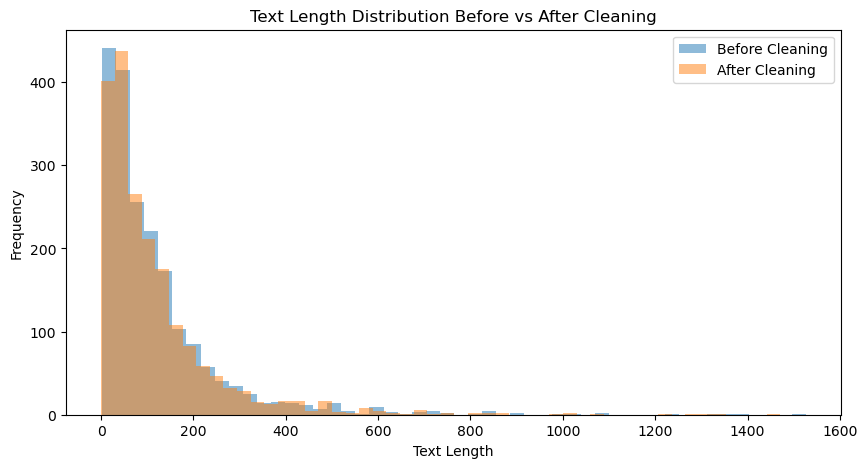

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(train['len_before'], bins=50, alpha=0.5, label='Before Cleaning')
plt.hist(train['len_after'], bins=50, alpha=0.5, label='After Cleaning')

plt.legend()
plt.title("Text Length Distribution Before vs After Cleaning")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

member 2 

In [96]:
# Parse string columns into actual Python objects
def parse_list(x):
    """Convert string '["food", "service"]' → actual Python list"""
    if isinstance(x, list): return x
    try:    return json.loads(x)
    except:
        try:    return ast.literal_eval(x)
        except: return []

def parse_dict(x):
    """Convert string '{"food": "positive"}' → actual Python dict"""
    if isinstance(x, dict): return x
    try:    return json.loads(x)
    except:
        try:    return ast.literal_eval(x)
        except: return {}

train["aspects_parsed"]    = train["aspects"].apply(parse_list)
train["sentiments_parsed"] = train["aspect_sentiments"].apply(parse_dict)

val["aspects_parsed"]    = val["aspects"].apply(parse_list)
val["sentiments_parsed"] = val["aspect_sentiments"].apply(parse_dict)

# Verify
print("Total reviews:", len(train))
print("\nSample row:")
print("  Text:       ", str(train["review_text"].iloc[2])[:80])
print("  Aspects:    ", train["aspects_parsed"].iloc[2])
print("  Sentiments: ", train["sentiments_parsed"].iloc[2])
print("  Types:      ", type(train["aspects_parsed"].iloc[2]),
                         type(train["sentiments_parsed"].iloc[2]))

Total reviews: 1971

Sample row:
  Text:        تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص
الاكل يعني 
  Aspects:     ['service', 'delivery', 'food']
  Sentiments:  {'service': 'negative', 'delivery': 'negative', 'food': 'neutral'}
  Types:       <class 'list'> <class 'dict'>


In [97]:


ASPECTS = [
    "food",            # 0  → الأكل
    "service",         # 1  → الخدمة
    "price",           # 2  → السعر
    "cleanliness",     # 3  → النظافة
    "delivery",        # 4  → التوصيل
    "ambiance",        # 5  → الأجواء
    "app_experience",  # 6  → تجربة التطبيق
    "general",         # 7  → عام
    "none"             # 8  → لا يوجد جانب محدد
]

SENTIMENTS = [
    "positive",   # 0
    "negative",   # 1
    "neutral"     # 2
]

# Create mappings (name → number and number → name)
ASP2IDX  = {a: i for i, a in enumerate(ASPECTS)}
IDX2ASP  = {i: a for a, i in ASP2IDX.items()}
SENT2IDX = {s: i for i, s in enumerate(SENTIMENTS)}
IDX2SENT = {i: s for s, i in SENT2IDX.items()}

# Print for verification
print("ASPECT MAPPING:")
for name, idx in ASP2IDX.items():
    print(f"  {idx} → {name}")

print("\nSENTIMENT MAPPING:")
for name, idx in SENT2IDX.items():
    print(f"  {idx} → {name}")

# Validate against dataset — make sure all aspects in data exist in our taxonomy
all_aspects_in_data = set(a for row in train["aspects_parsed"] for a in row)
all_sents_in_data   = set(s for d in train["sentiments_parsed"] for s in d.values())

unknown_aspects = all_aspects_in_data - set(ASPECTS)
unknown_sents   = all_sents_in_data - set(SENTIMENTS)

if unknown_aspects:
    print(f"\n WARNING: Unknown aspects in data: {unknown_aspects}")
else:
    print("\n All aspects in data match taxonomy")

if unknown_sents:
    print(f" WARNING: Unknown sentiments in data: {unknown_sents}")
else:
    print(" All sentiments in data match taxonomy")

ASPECT MAPPING:
  0 → food
  1 → service
  2 → price
  3 → cleanliness
  4 → delivery
  5 → ambiance
  6 → app_experience
  7 → general
  8 → none

SENTIMENT MAPPING:
  0 → positive
  1 → negative
  2 → neutral

 All aspects in data match taxonomy
 All sentiments in data match taxonomy


In [98]:

def encode_aspects(aspects_list):
    """
    Input:  ["food", "service"]
    Output: [1, 1, 0, 0, 0, 0, 0, 0, 0]  (float32)
    """
    vec = np.zeros(len(ASPECTS), dtype=np.float32)
    for asp in aspects_list:
        if asp in ASP2IDX:
            vec[ASP2IDX[asp]] = 1.0
    return vec

def encode_sentiments(sentiments_dict):
    """
    Input:  {"food": "positive", "service": "negative"}
    Output: [0, 1, -1, -1, -1, -1, -1, -1, -1]  (int64)
   
    -1 = aspect not present (will be masked in loss)
     0 = positive
     1 = negative
     2 = neutral
    """
    vec = np.full(len(ASPECTS), -1, dtype=np.int64)
    for asp, sent in sentiments_dict.items():
        if asp in ASP2IDX:
            vec[ASP2IDX[asp]] = SENT2IDX.get(sent, 2)  # default neutral
    return vec

# Apply to dataset
train["asp_labels"]  = train["aspects_parsed"].apply(encode_aspects)
train["sent_labels"] = train["sentiments_parsed"].apply(encode_sentiments)

# Apply to validation (has labels)
val["asp_labels"]  = val["aspects_parsed"].apply(encode_aspects)
val["sent_labels"] = val["sentiments_parsed"].apply(encode_sentiments)

# Show detailed example
for i in [0, 2, 5]:
    print(f"Review {i}: {str(train['review_text'].iloc[i])[:80]}")
    print(f"Aspects:    {train['aspects_parsed'].iloc[i]}")
    print(f"Sentiments: {train['sentiments_parsed'].iloc[i]}")
    print()
    print(f"{'Aspect':<18} {'Present?':<10} {'Sentiment':<12} {'Encoded'}")
    print("-" * 55)
    for j, asp in enumerate(ASPECTS):
        present   = " Yes" if train["asp_labels"].iloc[i][j] == 1 else " No"
        sent_idx  = train["sent_labels"].iloc[i][j]
        sent_name = IDX2SENT[sent_idx] if sent_idx != -1 else "---"
        print(f"{asp:<18} {present:<10} {sent_name:<12} asp={int(train['asp_labels'].iloc[i][j])} sent={sent_idx}")

Review 0: لا يوجد الدفع بالبطاقه عند الاستلام
Aspects:    ['app_experience', 'delivery']
Sentiments: {'app_experience': 'negative', 'delivery': 'negative'}

Aspect             Present?   Sentiment    Encoded
-------------------------------------------------------
food                No        ---          asp=0 sent=-1
service             No        ---          asp=0 sent=-1
price               No        ---          asp=0 sent=-1
cleanliness         No        ---          asp=0 sent=-1
delivery            Yes       negative     asp=1 sent=1
ambiance            No        ---          asp=0 sent=-1
app_experience      Yes       negative     asp=1 sent=1
general             No        ---          asp=0 sent=-1
none                No        ---          asp=0 sent=-1
Review 2: تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص
الاكل يعني 
Aspects:    ['service', 'delivery', 'food']
Sentiments: {'service': 'negative', 'delivery': 'negative', 'food': 'neutral'}

Aspect    

In [99]:
Y_aspects    = np.stack(train["asp_labels"].values)     # (1971, 9)
Y_sentiments = np.stack(train["sent_labels"].values)    # (1971, 9)

print("Y_aspects shape:   ", Y_aspects.shape)
print("Y_sentiments shape:", Y_sentiments.shape)

#  Verify: count labels per aspect
print(f"\n{'Aspect':<18} {'Present':<10} {'Absent':<10} {'% Present'}")
for j, asp in enumerate(ASPECTS):
    present = int(Y_aspects[:, j].sum())
    absent  = len(Y_aspects) - present
    pct     = present / len(Y_aspects) * 100
    print(f"{asp:<18} {present:<10} {absent:<10} {pct:.1f}%")

#  Verify: sentiment distribution per aspect 
print(f"\n{'Aspect':<18} {'Positive':<10} {'Negative':<10} {'Neutral':<10}")
for j, asp in enumerate(ASPECTS):
    mask = Y_sentiments[:, j] != -1  # only present aspects
    if mask.sum() == 0:
        print(f"{asp:<18} {'---':<10} {'---':<10} {'---':<10}")
        continue
    pos = int((Y_sentiments[:, j] == 0).sum())
    neg = int((Y_sentiments[:, j] == 1).sum())
    neu = int((Y_sentiments[:, j] == 2).sum())
    print(f"{asp:<18} {pos:<10} {neg:<10} {neu:<10}")



Y_aspects shape:    (1971, 9)
Y_sentiments shape: (1971, 9)

Aspect             Present    Absent     % Present
food               454        1517       23.0%
service            988        983        50.1%
price              354        1617       18.0%
cleanliness        185        1786       9.4%
delivery           161        1810       8.2%
ambiance           378        1593       19.2%
app_experience     453        1518       23.0%
general            303        1668       15.4%
none               57         1914       2.9%

Aspect             Positive   Negative   Neutral   
food               246        177        31        
service            529        449        10        
price              110        233        11        
cleanliness        109        75         1         
delivery           18         142        1         
ambiance           268        101        9         
app_experience     111        327        15        
general            255        34         14        

ASPECT WEIGHTS (for BCEWithLogitsLoss pos_weight):

Aspect             Count    Weight   Severity
food               454      2.18      MODERATE
service            988      1.0       OK
price              354      2.79      MODERATE
cleanliness        185      5.34      HIGH
delivery           161      6.14      HIGH
ambiance           378      2.61      MODERATE
app_experience     453      2.18      MODERATE
general            303      3.26      MODERATE
none               57       17.33     CRITICAL



SENTIMENT WEIGHTS (for CrossEntropyLoss weight):

Sentiment       Count    Weight   Severity
--------------------------------------------------
positive        1646     1.0      OK
negative        1538     1.07     OK
neutral         149      11.05     CRITICAL


C:\Users\LaLa.STORE\AppData\Local\Temp\ipykernel_31060\1827912896.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ASPECTS, rotation=45, ha="right", fontsize=8)


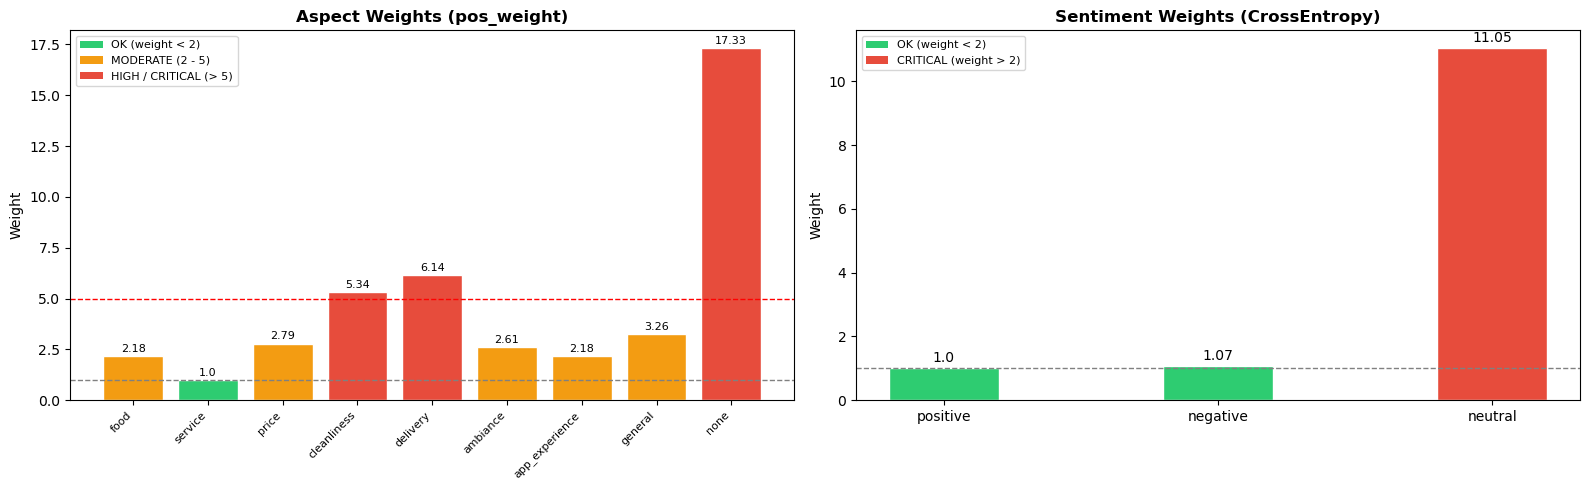

In [100]:
 
aspect_counts = {asp: int(Y_aspects[:, j].sum()) for j, asp in enumerate(ASPECTS)}
max_asp_count = max(aspect_counts.values())

aspect_weights = []
print("ASPECT WEIGHTS (for BCEWithLogitsLoss pos_weight):")
print(f"\n{'Aspect':<18} {'Count':<8} {'Weight':<8} {'Severity'}")
for asp in ASPECTS:
    cnt = aspect_counts[asp]
    w   = round(max_asp_count / max(cnt, 1), 2)
    aspect_weights.append(w)
    if w > 10:    severity = " CRITICAL"
    elif w > 5:   severity = " HIGH"
    elif w > 2:   severity = " MODERATE"
    else:         severity = " OK"
    print(f"{asp:<18} {cnt:<8} {w:<8} {severity}")

#  SENTIMENT WEIGHTS 
all_sents    = Y_sentiments[Y_sentiments != -1]  # exclude absent
sent_counter = Counter(all_sents.tolist())
max_sent_count = max(sent_counter.values())

sent_weights = []
print(f"\nSENTIMENT WEIGHTS (for CrossEntropyLoss weight):")
print(f"\n{'Sentiment':<15} {'Count':<8} {'Weight':<8} {'Severity'}")
print("-" * 50)
for s in SENTIMENTS:
    idx = SENT2IDX[s]
    cnt = sent_counter.get(idx, 1)
    w   = round(max_sent_count / max(cnt, 1), 2)
    sent_weights.append(w)
    severity = " CRITICAL" if w > 5 else "OK"
    print(f"{s:<15} {cnt:<8} {w:<8} {severity}")

#  Visualize 
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aspect weights
colors_asp = ["#E74C3C" if w > 5 else "#F39C12" if w > 2 else "#2ECC71"
              for w in aspect_weights]
axes[0].bar(ASPECTS, aspect_weights, color=colors_asp, edgecolor="white")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[0].axhline(5.0, color="red",  linestyle="--", linewidth=1)
axes[0].set_xticklabels(ASPECTS, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Aspect Weights (pos_weight)", fontweight="bold")
axes[0].set_ylabel("Weight")
for i, w in enumerate(aspect_weights):
    axes[0].text(i, w + 0.2, str(w), ha="center", fontsize=8)

# Legend for aspect colors
asp_legend = [
    Patch(facecolor="#2ECC71", label="OK (weight < 2)"),
    Patch(facecolor="#F39C12", label="MODERATE (2 - 5)"),
    Patch(facecolor="#E74C3C", label="HIGH / CRITICAL (> 5)")
]
axes[0].legend(handles=asp_legend, fontsize=8, loc="upper left")

# Sentiment weights
colors_sent = ["#2ECC71" if w < 2 else "#E74C3C" for w in sent_weights]
axes[1].bar(SENTIMENTS, sent_weights, color=colors_sent, edgecolor="white", width=0.4)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Sentiment Weights (CrossEntropy)", fontweight="bold")
axes[1].set_ylabel("Weight")
for i, w in enumerate(sent_weights):
    axes[1].text(i, w + 0.2, str(w), ha="center", fontsize=10)

# Legend for sentiment colors
sent_legend = [
    Patch(facecolor="#2ECC71", label="OK (weight < 2)"),
    Patch(facecolor="#E74C3C", label="CRITICAL (weight > 2)")
]
axes[1].legend(handles=sent_legend, fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("class_weights.png", dpi=150, bbox_inches="tight")
plt.show()

In [101]:

# Val is a separate file
val = pd.read_excel("DeepX_validation.xlsx")

# Parse aspects & sentiments for val
val["aspects_parsed"]    = val["aspects"].apply(parse_list)
val["sentiments_parsed"] = val["aspect_sentiments"].apply(parse_dict)

# Encode labels for val
val["asp_labels"]  = val["aspects_parsed"].apply(encode_aspects)
val["sent_labels"] = val["sentiments_parsed"].apply(encode_sentiments)

# Build matrices (train was already processed in earlier cells)
Y_train_aspects    = np.stack(train["asp_labels"].values)
Y_train_sentiments = np.stack(train["sent_labels"].values)
Y_val_aspects      = np.stack(val["asp_labels"].values)
Y_val_sentiments   = np.stack(val["sent_labels"].values)

print("FINAL LABEL OUTPUT")
print(f"Train reviews:      {len(train)}")
print(f"Val reviews:        {len(val)}")
print(f"Y_train_aspects:    {Y_train_aspects.shape}")
print(f"Y_train_sentiments: {Y_train_sentiments.shape}")
print(f"Y_val_aspects:      {Y_val_aspects.shape}")
print(f"Y_val_sentiments:   {Y_val_sentiments.shape}")

# Verify no data leakage
train_ids = set(train["review_id"].tolist())
val_ids   = set(val["review_id"].tolist())
overlap   = train_ids & val_ids
print(f"\nTrain/Val overlap: {len(overlap)} reviews")
if len(overlap) == 0:
    print("No data leakage — datasets are completely separate")
else:
    print(f"WARNING: {len(overlap)} reviews appear in BOTH sets!")

# Verify val has all aspects
print(f"\n{'Aspect':<18} {'Train':<8} {'Val':<8} {'Val OK?'}")
print("-" * 45)
for j, asp in enumerate(ASPECTS):
    t_cnt = int(Y_train_aspects[:, j].sum())
    v_cnt = int(Y_val_aspects[:, j].sum())
    flag  = "OK" if v_cnt >= 3 else "LOW - WARNING"
    print(f"{asp:<18} {t_cnt:<8} {v_cnt:<8} {flag}")

# Save
label_data = {
    "Y_train_aspects":    Y_train_aspects,
    "Y_train_sentiments": Y_train_sentiments,
    "Y_val_aspects":      Y_val_aspects,
    "Y_val_sentiments":   Y_val_sentiments,
    "aspect_weights":     aspect_weights,
    "sent_weights":       sent_weights,
    "ASP2IDX":            ASP2IDX,
    "IDX2ASP":            IDX2ASP,
    "SENT2IDX":           SENT2IDX,
    "IDX2SENT":           IDX2SENT,
    "ASPECTS":            ASPECTS,
    "SENTIMENTS":         SENTIMENTS,
}


FINAL LABEL OUTPUT
Train reviews:      1971
Val reviews:        500
Y_train_aspects:    (1971, 9)
Y_train_sentiments: (1971, 9)
Y_val_aspects:      (500, 9)
Y_val_sentiments:   (500, 9)

Train/Val overlap: 0 reviews
No data leakage — datasets are completely separate

Aspect             Train    Val      Val OK?
---------------------------------------------
food               454      102      OK
service            988      253      OK
price              354      80       OK
cleanliness        185      51       OK
delivery           161      48       OK
ambiance           378      100      OK
app_experience     453      120      OK
general            303      74       OK
none               57       12       OK


In [102]:
train.head()

,review_id,review_text,star_rating,business_category,platform,aspects,aspect_sentiments,clean_text,len_before,len_after,aspects_parsed,sentiments_parsed,asp_labels,sent_labels
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne...",لا يوجد الدفع بالبطاقه عند الاستلام,35,35,"[app_experience, delivery]","{'app_experience': 'negative', 'delivery': 'ne...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0]","[-1, -1, -1, -1, 1, -1, 1, -1, -1]"
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit...",المكان نضيف وجميل وقعدته تحفه والخدمة فوق المت...,94,93,"[cleanliness, ambiance, service]","{'cleanliness': 'positive', 'ambiance': 'posit...","[0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[-1, 0, -1, 0, -1, 0, -1, -1, -1]"
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""...",تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,104,104,"[service, delivery, food]","{'service': 'negative', 'delivery': 'negative'...","[1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[2, 1, -1, -1, 1, -1, -1, -1, -1]"
3,3024,احلي مكان فزايد,5,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}",احلي مكان فزايد,15,15,[general],{'general': 'positive'},"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[-1, -1, -1, -1, -1, -1, -1, 0, -1]"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}",الفطير حلو جدا الاحجام تحفة بالنسبه لسعر فا يع...,288,285,"[food, price]","{'food': 'positive', 'price': 'positive'}","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0, -1, 0, -1, -1, -1, -1, -1, -1]"


member 3

In [103]:
train["model_input"] = (
    train["clean_text"].astype(str) +
    " [CAT: " + train["business_category"].astype(str) + "]" +
    " [RATING: " + train["star_rating"].astype(str) + "]"
)

val["model_input"] = (
    val["clean_text"].astype(str) +
    " [CAT: " + val["business_category"].astype(str) + "]" +
    " [RATING: " + val["star_rating"].astype(str) + "]"
)

KeyError: 'clean_text'

In [64]:
train.head()

,review_id,review_text,star_rating,business_category,platform,aspects,aspect_sentiments,clean_text,len_before,len_after,aspects_parsed,sentiments_parsed,asp_labels,sent_labels,model_input
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne...",لا يوجد الدفع بالبطاقه عند الاستلام,35,35,"[app_experience, delivery]","{'app_experience': 'negative', 'delivery': 'ne...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0]","[-1, -1, -1, -1, 1, -1, 1, -1, -1]",لا يوجد الدفع بالبطاقه عند الاستلام [CAT: ecom...
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit...",المكان نضيف وجميل وقعدته تحفه والخدمة فوق المت...,94,93,"[cleanliness, ambiance, service]","{'cleanliness': 'positive', 'ambiance': 'posit...","[0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[-1, 0, -1, 0, -1, 0, -1, -1, -1]",المكان نضيف وجميل وقعدته تحفه والخدمة فوق المت...
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""...",تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,104,104,"[service, delivery, food]","{'service': 'negative', 'delivery': 'negative'...","[1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[2, 1, -1, -1, 1, -1, -1, -1, -1]",تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...
3,3024,احلي مكان فزايد,5,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}",احلي مكان فزايد,15,15,[general],{'general': 'positive'},"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[-1, -1, -1, -1, -1, -1, -1, 0, -1]",احلي مكان فزايد [CAT: مطعم مأكولات ومشروبات] [...
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}",الفطير حلو جدا الاحجام تحفة بالنسبه لسعر فا يع...,288,285,"[food, price]","{'food': 'positive', 'price': 'positive'}","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0, -1, 0, -1, -1, -1, -1, -1, -1]",الفطير حلو جدا الاحجام تحفة بالنسبه لسعر فا يع...
